# ⚽ Transfermarkt — Full ML Regression Pipeline
**Dataset:** `transfermarkt_cleaned.csv`  
**Target:** `log_market_value`

| Stage | Details |
|---|---|
| Data Cleaning | Drop IDs, leakage cols, encode categoricals |
| EDA | Distributions, correlation analysis |
| Feature Selection | Drop correlated features (threshold = 0.90) |
| Split | 60% Train / 20% Val / 20% Test |
| Preprocessing | Median imputer + StandardScaler (fit on train only) |
| Models | Linear, Ridge, Lasso, KNN, XGBoost, LightGBM |
| Evaluation | CV RMSE, Val R², Test R², MAE |


## 1. Imports & Configuration

In [18]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.neighbors        import KNeighborsRegressor
from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# ── Colour palette ──
P = {
    'bg':'#0D0F1A', 'card':'#13162B', 'card2':'#181B30',
    'accent1':'#7C6FFF', 'accent2':'#FF6B8A', 'accent3':'#3FEFB4',
    'accent4':'#FFB347', 'accent5':'#00BCD4',
    'text':'#E8EAF6', 'subtext':'#8E8EB8', 'grid':'#252840', 'best':'#FFD700'
}
plt.rcParams.update({
    'figure.facecolor': P['bg'],  'axes.facecolor': P['card'],
    'axes.edgecolor':   P['grid'],'axes.labelcolor': P['text'],
    'xtick.color':      P['subtext'], 'ytick.color': P['subtext'],
    'text.color':       P['text'],    'grid.color':  P['grid'],
    'grid.linestyle':   '--',         'grid.alpha':  0.5,
    'figure.dpi':       130,
})
print('✓ Imports complete')

✓ Imports complete


## 2. Load & Inspect Data

In [19]:
df_raw = pd.read_csv('C:\\Users\\Data-DCS\\OneDrive\\Desktop\\Ai\\DEPI-ML-PROJECT\\ML\\data\\processed\\transfermarkt_cleaned.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (39224, 49)
Columns: ['player_id', 'last_name', 'name', 'last_season', 'current_club_id', 'country_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'international_caps', 'international_goals', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur', 'age', 'log_market_value', 'contract_years_left', 'total_games', 'total_goals', 'total_assists', 'total_yellow', 'total_red', 'total_minutes', 'avg_minutes', 'goals_per_game', 'assists_per_game', 'latest_valuation', 'latest_val_date', 'peak_valuation', 'num_transfers', 'total_transfer_fee', 'max_transfer_fee', 'avg_transfer_fee', 'goals_per_90', 'assists_per_90', 'goal_contributions', 'gc_per_90', 'discipline_score', 'experience_score', 'intl_ratio', 'value_growth', 'is_international', 'position_enc', 'foot_enc']


,player_id,last_name,name,last_season,current_club_id,country_of_birth,country_of_citizenship,date_of_birth,sub_position,position,...,assists_per_90,goal_contributions,gc_per_90,discipline_score,experience_score,intl_ratio,value_growth,is_international,position_enc,foot_enc
0,10,Klose,Miroslav Klose,2015,398,Poland,Germany,1978-06-09,Centre-Forward,Attack,...,0.255450,73.0,0.745913,19.0,97.867111,0.0,29.999970,0,3.0,0.0
1,26,Weidenfeller,Roman Weidenfeller,2017,16,Germany,Germany,1980-08-06,Goalkeeper,Goalkeeper,...,0.000000,0.0,0.000000,10.0,150.088178,0.0,10.666652,0,0.0,1.0
2,65,Berbatov,Dimitar Berbatov,2015,1091,Bulgaria,Bulgaria,1981-01-30,Centre-Forward,Attack,...,0.133136,51.0,0.522303,14.0,97.644733,0.0,34.499966,0,3.0,0.0


In [20]:
print('Dtypes:')
print(df_raw.dtypes)
print(f'\nDuplicates: {df_raw.duplicated().sum()}')
print(f'\nMissing values:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Dtypes:
player_id                                 int64
last_name                                   str
name                                        str
last_season                               int64
current_club_id                           int64
country_of_birth                            str
country_of_citizenship                      str
date_of_birth                               str
sub_position                                str
position                                    str
foot                                        str
height_in_cm                            float64
contract_expiration_date                    str
international_caps                      float64
international_goals                     float64
current_club_domestic_competition_id        str
current_club_name                           str
market_value_in_eur                     float64
highest_market_value_in_eur             float64
age                                     float64
log_market_value                

## 3. Data Cleaning

**Steps:**
- Drop identifier / date columns → no predictive signal, cause ID leakage
- Drop **leakage** columns (`market_value_in_eur`, `highest_market_value_in_eur`, `latest_valuation`, `peak_valuation`) — these are direct derivations of the target
- Ordinal-encode remaining `object` columns via pandas category codes (NaN → kept as NaN for imputer)


Categorical cols to encode: ['country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot']
Shape after cleaning: (39224, 35)
Duplicates: 7
Remaining missing:
country_of_birth          2929
country_of_citizenship     256
sub_position               124
position                   124
foot                      2882
dtype: int64


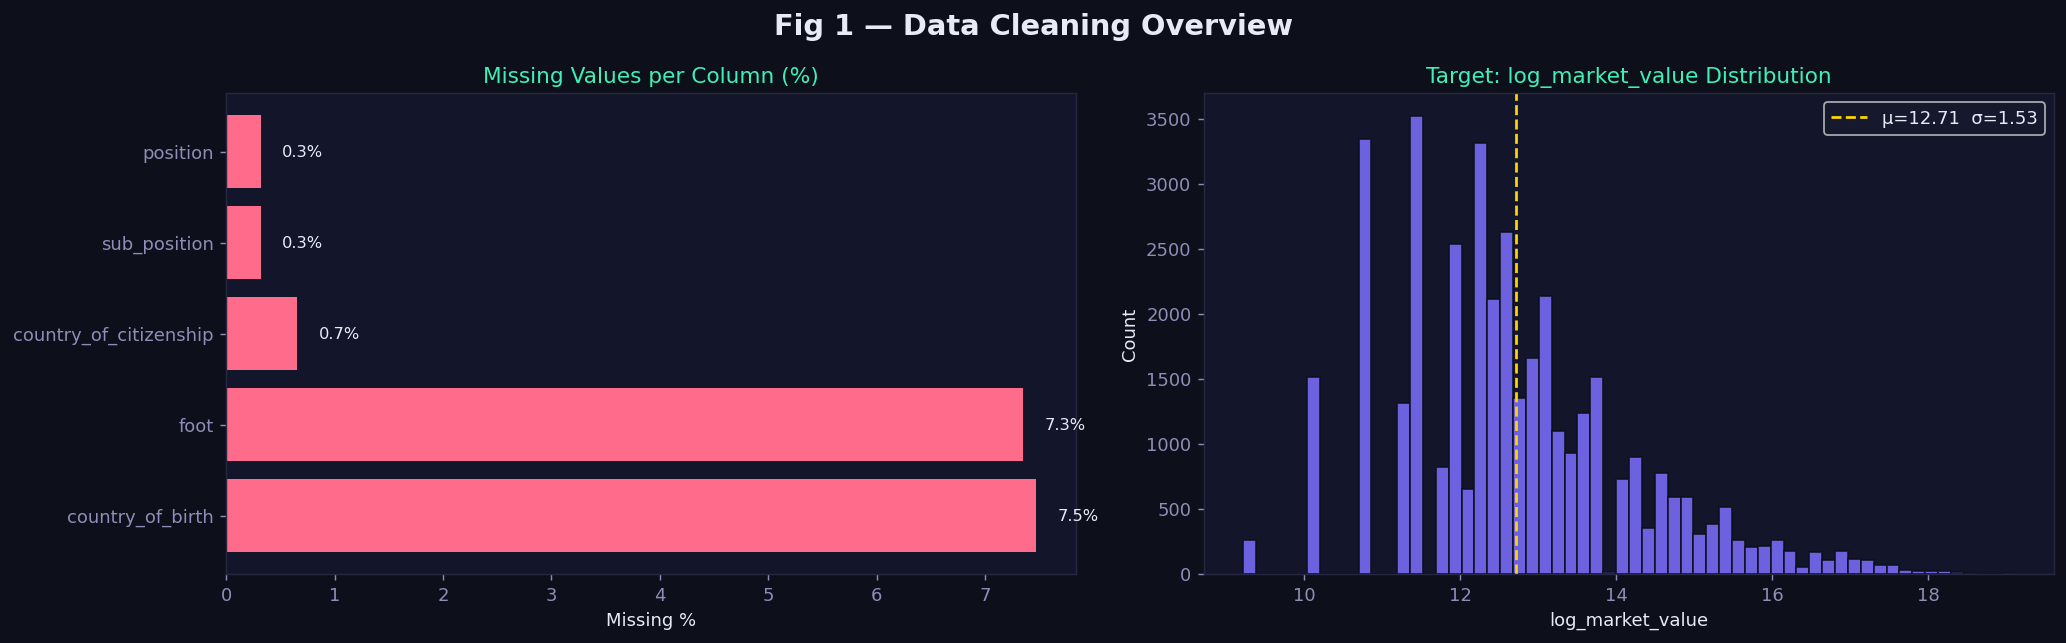

In [21]:
TARGET = 'log_market_value'

ID_LIKE = [
    'player_id', 'last_name', 'name', 'current_club_id', 'date_of_birth',
    'latest_val_date', 'current_club_name', 'current_club_domestic_competition_id',
    'last_season', 'contract_expiration_date'
]
LEAKAGE = [
    'market_value_in_eur', 'highest_market_value_in_eur',
    'latest_valuation', 'peak_valuation'
]

df = df_raw.drop(columns=ID_LIKE + LEAKAGE, errors='ignore')

# Encode categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical cols to encode: {cat_cols}')
for c in cat_cols:
    df[c] = df[c].astype('category').cat.codes.replace(-1, float('nan'))

print(f'Shape after cleaning: {df.shape}')
print(f'Duplicates: {df.duplicated().sum()}')
missing = df.isnull().sum(); missing = missing[missing > 0]
print(f'Remaining missing:\n{missing}')

# ── Fig 1: Missing values % + Target distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=P['bg'])
fig.suptitle('Fig 1 — Data Cleaning Overview', color=P['text'], fontsize=16, fontweight='bold')

# Missing bar chart
mp = df.isnull().mean() * 100
mp = mp[mp > 0].sort_values(ascending=False)
axes[0].barh(mp.index, mp.values, color=P['accent2'])
axes[0].set_title('Missing Values per Column (%)', color=P['accent3'])
axes[0].set_xlabel('Missing %', color=P['text'])
for i, v in enumerate(mp.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', color=P['text'], fontsize=9)

# Target distribution
axes[1].hist(df[TARGET], bins=60, color=P['accent1'], alpha=0.85, edgecolor=P['bg'])
axes[1].axvline(df[TARGET].mean(), color=P['best'], linestyle='--',
                label=f"μ={df[TARGET].mean():.2f}  σ={df[TARGET].std():.2f}")
axes[1].set_title('Target: log_market_value Distribution', color=P['accent3'])
axes[1].set_xlabel('log_market_value', color=P['text'])
axes[1].set_ylabel('Count', color=P['text'])
axes[1].legend(facecolor=P['card2'], labelcolor=P['text'])

plt.tight_layout()
plt.show()

# ── Export cleaned CSV (no IDs, no leakage, categoricals encoded) ──

In [22]:
df_export = df_raw.drop(columns=ID_LIKE + LEAKAGE, errors='ignore').copy()

for c in df_export.select_dtypes(include='object').columns:
    df_export[c] = df_export[c].astype('category').cat.codes.replace(-1, float('nan'))

df_export.to_csv('transfermarkt_cleaned_final.csv', index=False)
print(f'✓ Saved transfermarkt_cleaned_final.csv')
print(f'  Shape : {df_export.shape}')
print(f'  Columns dropped: {ID_LIKE + LEAKAGE}')
df_export.head(3)


✓ Saved transfermarkt_cleaned_final.csv
  Shape : (39224, 35)
  Columns dropped: ['player_id', 'last_name', 'name', 'current_club_id', 'date_of_birth', 'latest_val_date', 'current_club_name', 'current_club_domestic_competition_id', 'last_season', 'contract_expiration_date', 'market_value_in_eur', 'highest_market_value_in_eur', 'latest_valuation', 'peak_valuation']


,country_of_birth,country_of_citizenship,sub_position,position,foot,height_in_cm,international_caps,international_goals,age,log_market_value,...,assists_per_90,goal_contributions,gc_per_90,discipline_score,experience_score,intl_ratio,value_growth,is_international,position_enc,foot_enc
0,135.0,63.0,3.0,0.0,2.0,184.0,0.0,0.0,47.9,13.815512,...,0.255450,73.0,0.745913,19.0,97.867111,0.0,29.999970,0,3.0,0.0
1,60.0,63.0,5.0,2.0,1.0,190.0,0.0,0.0,45.7,13.527830,...,0.000000,0.0,0.000000,10.0,150.088178,0.0,10.666652,0,0.0,1.0
2,19.0,25.0,3.0,0.0,NaN,182.0,0.0,0.0,45.2,13.815512,...,0.133136,51.0,0.522303,14.0,97.644733,0.0,34.499966,0,3.0,0.0


## 4. EDA — Exploratory Data Analysis

- Target is near-normal (μ≈12.71, σ≈1.53) — log transformation was appropriate
- Several features are heavily right-skewed (transfer fees, goals, minutes)
- `age`, `intl_ratio`, `goals_per_90` have the strongest raw correlations with target


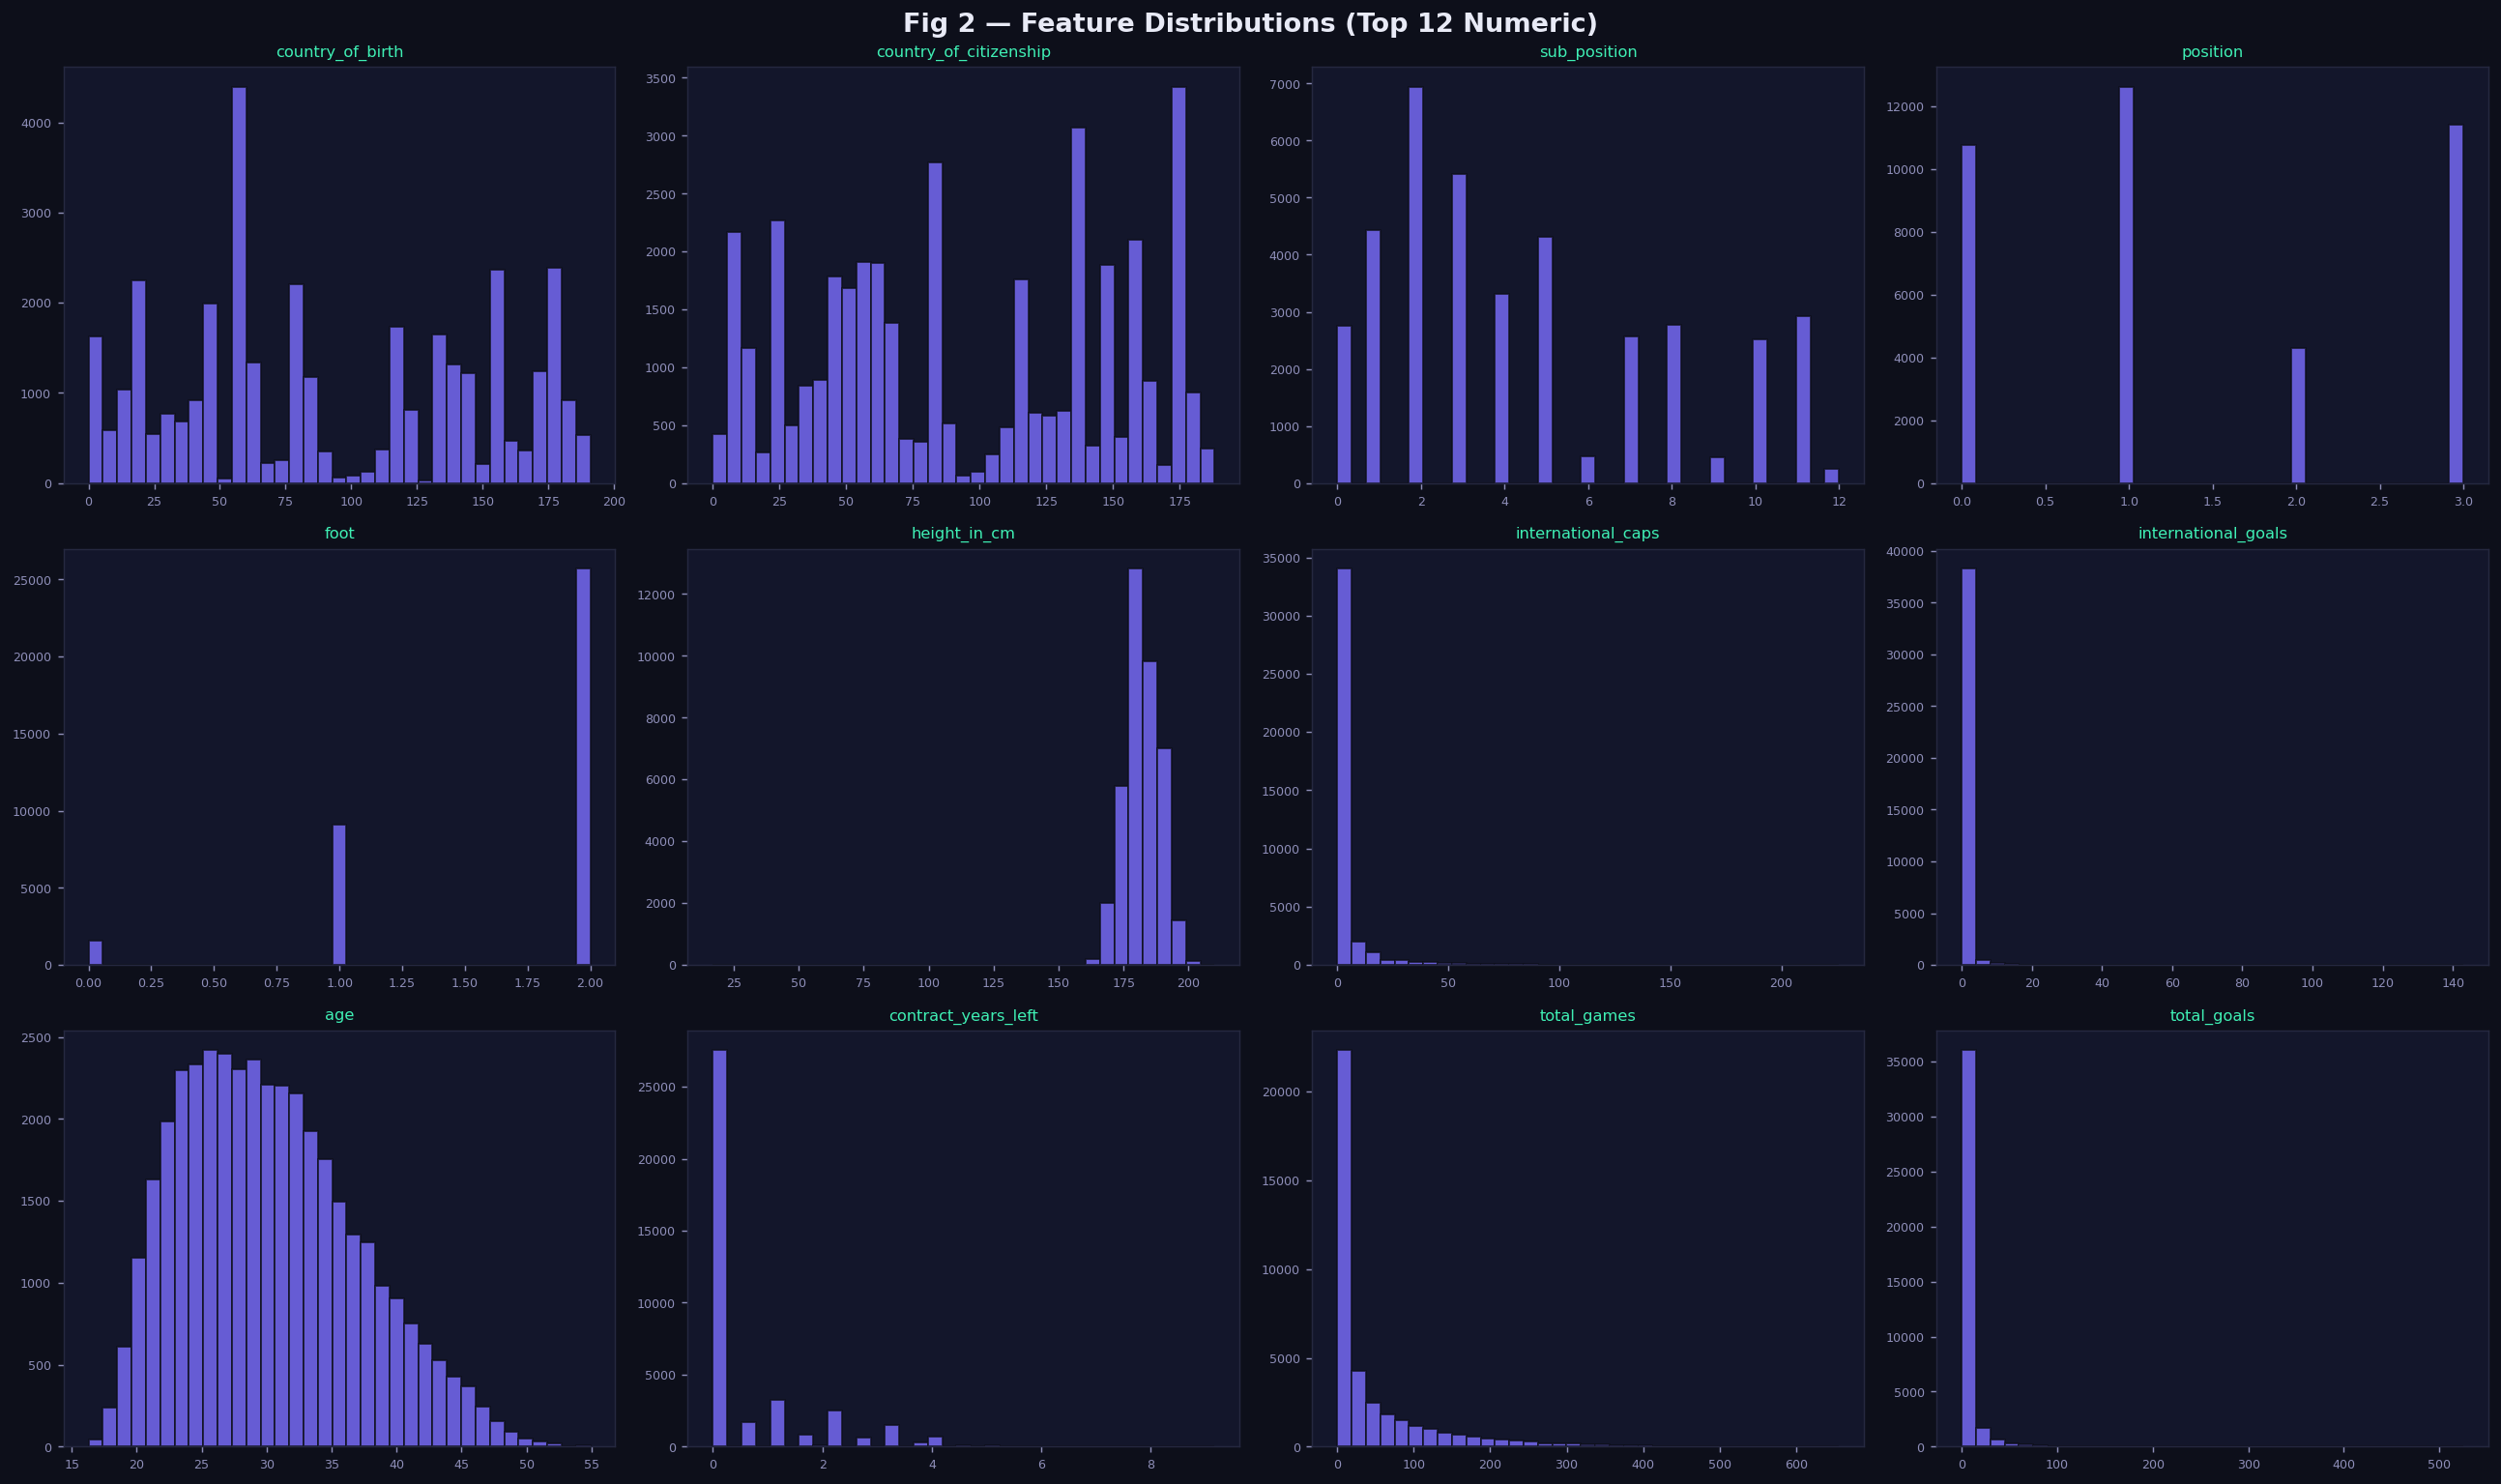

In [23]:
num_df = df.select_dtypes(include='number')
X_all  = num_df.drop(columns=[TARGET])

# ── Fig 2: Feature distributions (top 12 numeric cols) ──
top_features = X_all.columns[:12]
fig, axes = plt.subplots(3, 4, figsize=(20, 12), facecolor=P['bg'])
fig.suptitle('Fig 2 — Feature Distributions (Top 12 Numeric)', color=P['text'],
             fontsize=15, fontweight='bold')
for ax, col in zip(axes.flatten(), top_features):
    ax.hist(X_all[col].dropna(), bins=35, color=P['accent1'], alpha=0.8, edgecolor=P['bg'])
    ax.set_title(col, color=P['accent3'], fontsize=9)
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

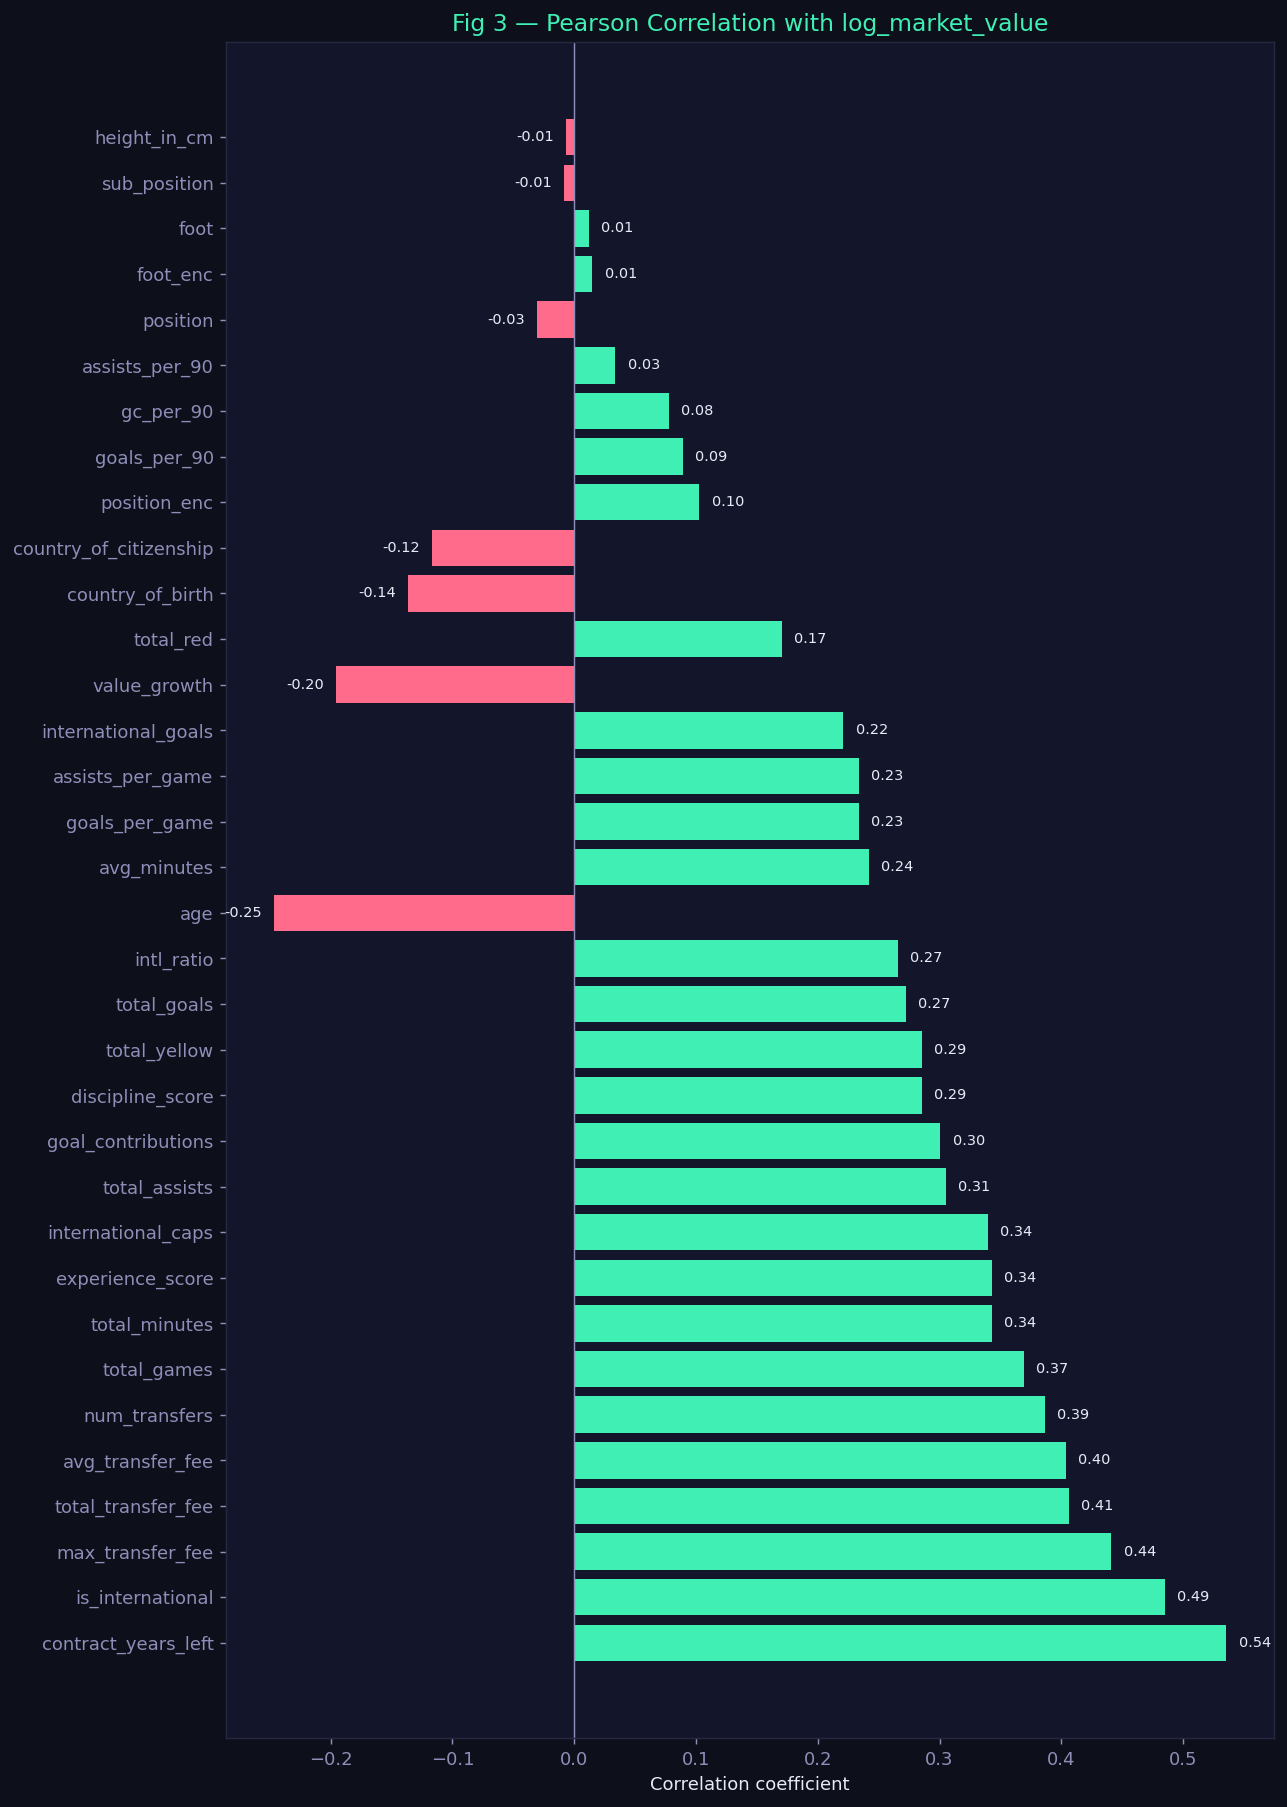

Top 5 positive correlations:
contract_years_left    0.535574
is_international       0.485055
max_transfer_fee       0.441096
total_transfer_fee     0.406100
avg_transfer_fee       0.403629

Top 5 negative correlations:
position       -0.030523
foot_enc        0.014943
foot            0.012219
sub_position   -0.008197
height_in_cm   -0.006518


In [24]:
# ── Fig 3: Pearson correlation of every feature with the target ──
corr_target = num_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 14), facecolor=P['bg'])
colors_c = [P['accent3'] if v > 0 else P['accent2'] for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_c)
ax.axvline(0, color=P['subtext'], linewidth=0.8)
ax.set_title('Fig 3 — Pearson Correlation with log_market_value',
             color=P['accent3'], fontsize=13)
ax.set_xlabel('Correlation coefficient', color=P['text'])
for i, v in enumerate(corr_target.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right',
            color=P['text'], fontsize=8)
plt.tight_layout()
plt.show()

print('Top 5 positive correlations:')
print(corr_target.head(5).to_string())
print('\nTop 5 negative correlations:')
print(corr_target.tail(5).to_string())

## 5. Feature Selection — Correlation Threshold (0.90)

For every pair of features with |correlation| > **0.90**:
- Keep the one with **higher absolute correlation to the target**
- Drop the other

**7 columns dropped:** `experience_score`, `foot`, `goal_contributions`, `total_goals`, `total_minutes`, `total_transfer_fee`, `total_yellow`  
**Features: 34 → 27**


Threshold: 0.9
Dropped (7 cols): ['experience_score', 'foot', 'goal_contributions', 'total_goals', 'total_minutes', 'total_transfer_fee', 'total_yellow']
Features: 34 → 27


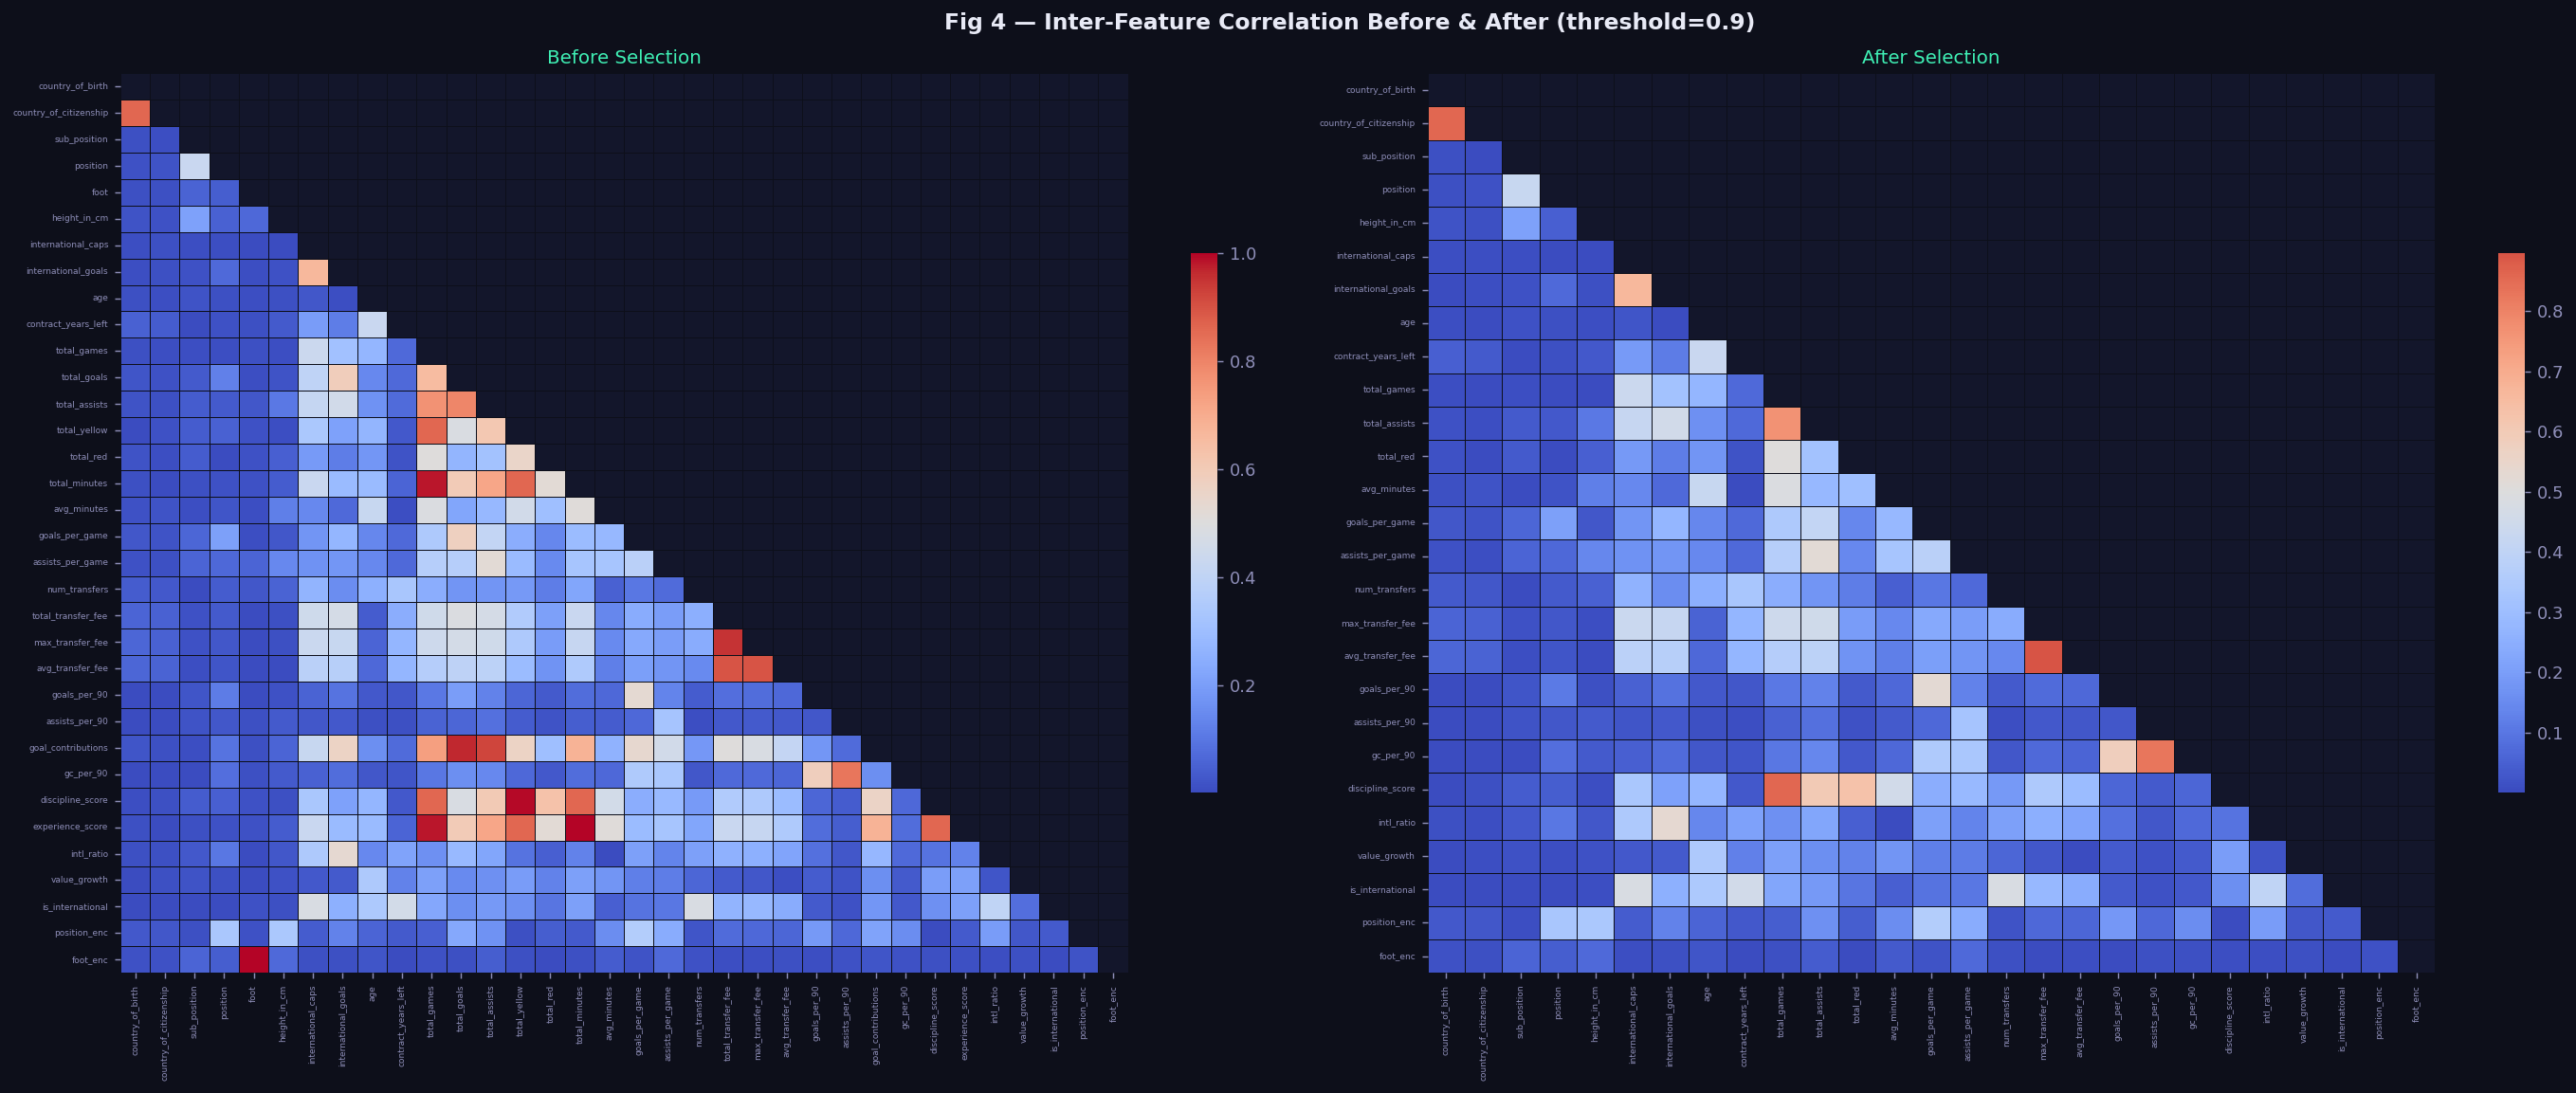

In [25]:
CORR_THRESHOLD = 0.90
corr_matrix = X_all.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
for col in upper_tri.columns:
    pairs = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    for pair in pairs:
        c1c = abs(corr_target.get(col, 0))
        c2c = abs(corr_target.get(pair, 0))
        to_drop.add(col if c1c < c2c else pair)

print(f'Threshold: {CORR_THRESHOLD}')
print(f'Dropped ({len(to_drop)} cols): {sorted(to_drop)}')

X = X_all.drop(columns=list(to_drop))
print(f'Features: {X_all.shape[1]} → {X.shape[1]}')

# ── Fig 4: Correlation heatmap before & after ──
fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor=P['bg'])
fig.suptitle(f'Fig 4 — Inter-Feature Correlation Before & After (threshold={CORR_THRESHOLD})',
             color=P['text'], fontsize=13, fontweight='bold')

for ax, data, title in zip(axes,
                            [corr_matrix, X.corr().abs()],
                            ['Before Selection', 'After Selection']):
    mask = np.triu(np.ones_like(data, dtype=bool))
    sns.heatmap(data, mask=mask, cmap='coolwarm', center=0.5,
                linewidths=0.3, linecolor=P['bg'], ax=ax,
                cbar_kws={'shrink': 0.6}, xticklabels=True, yticklabels=True)
    ax.set_title(title, color=P['accent3'], fontsize=11)
    ax.tick_params(axis='both', labelsize=5, colors=P['subtext'])
plt.tight_layout()
plt.show()

## 6. Three-Way Split (60 / 20 / 20)


In [26]:
FEATURE_NAMES = list(X.columns)
y = num_df[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print(f'Train : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {len(X_val):,}  rows  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.0f}%)')

Train : 23,534 rows  (60%)
Val   : 7,845  rows  (20%)
Test  : 7,845  rows  (20%)


## 7. Preprocessing (Fit on Train Only — No Leakage)


In [27]:
# Median imputer — handles remaining NaN in categoricals
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train),  columns=FEATURE_NAMES, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),        columns=FEATURE_NAMES, index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),       columns=FEATURE_NAMES, index=X_test.index)

# Standard scaler — used for linear models and KNN
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=FEATURE_NAMES, index=X_train.index)
X_val_sc   = pd.DataFrame(scaler.transform(X_val_imp),       columns=FEATURE_NAMES, index=X_val.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_imp),      columns=FEATURE_NAMES, index=X_test.index)

print('✓ Preprocessing complete')
print(f'  Train shape: {X_train_sc.shape}')

✓ Preprocessing complete
  Train shape: (23534, 27)


## 8. Model Training & Evaluation

| Model | Uses Scaled Data | Notes |
|---|---|---|
| Linear Regression | ✓ | Baseline |
| Ridge | ✓ | L2 regularisation, α=1 |
| Lasso | ✓ | L1 regularisation, α=0.001 |
| KNN | ✓ | k=7, distance-weighted |
| XGBoost | ✗ | Early stopping (20 rounds) on val |
| LightGBM | ✗ | Early stopping (20 rounds) on val |


In [28]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

MODELS = {
    'Linear Regression': (True,  LinearRegression()),
    'Ridge':             (True,  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'Lasso':             (True,  Lasso(alpha=0.001, max_iter=3000, random_state=RANDOM_STATE)),
    'KNN':               (True,  KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1)),
    'XGBoost':           (False, XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                                               subsample=0.8, colsample_bytree=0.8,
                                               random_state=RANDOM_STATE, verbosity=0)),
    'LightGBM':          (False, LGBMRegressor(n_estimators=200, learning_rate=0.1, num_leaves=31,
                                                subsample=0.8, random_state=RANDOM_STATE, verbosity=-1)),
}

results = {}
for name, (scale, est) in MODELS.items():
    Xtr = X_train_sc if scale else X_train_imp
    Xvl = X_val_sc   if scale else X_val_imp
    Xte = X_test_sc  if scale else X_test_imp

    # Cross-validation on training set
    cv = -cross_val_score(est, Xtr, y_train, cv=3,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)

    # Fit (with early stopping for boosting models)
    if name == 'XGBoost':
        est.set_params(early_stopping_rounds=20, eval_metric='rmse')
        est.fit(Xtr, y_train, eval_set=[(Xvl, y_val)], verbose=False)
    elif name == 'LightGBM':
        est.fit(Xtr, y_train, eval_set=[(Xvl, y_val)],
                callbacks=[early_stopping(20), log_evaluation(-1)])
    else:
        est.fit(Xtr, y_train)

    vr, vm, vr2 = metrics(y_val,  est.predict(Xvl))
    tr, tm, tr2 = metrics(y_test, est.predict(Xte))

    results[name] = dict(
        cv_rmse_mean=cv.mean(), cv_rmse_std=cv.std(),
        val_rmse=vr,  val_mae=vm,  val_r2=vr2,
        test_rmse=tr, test_mae=tm, test_r2=tr2,
        estimator=est, scale=scale
    )
    print(f'{name:20s}  CV:{cv.mean():.4f}±{cv.std():.4f}  '
          f'Val R²:{vr2:.4f}  Test R²:{tr2:.4f}')

Linear Regression     CV:1.0217±0.0078  Val R²:0.5338  Test R²:0.5478
Ridge                 CV:1.0217±0.0078  Val R²:0.5338  Test R²:0.5478
Lasso                 CV:1.0215±0.0075  Val R²:0.5336  Test R²:0.5478
KNN                   CV:1.0073±0.0066  Val R²:0.5530  Test R²:0.5579
XGBoost               CV:0.5176±0.0052  Val R²:0.8874  Test R²:0.8892
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[200]	valid_0's l2: 0.24259
LightGBM              CV:0.5031±0.0087  Val R²:0.8946  Test R²:0.8966


## 9. Results & Visualisations


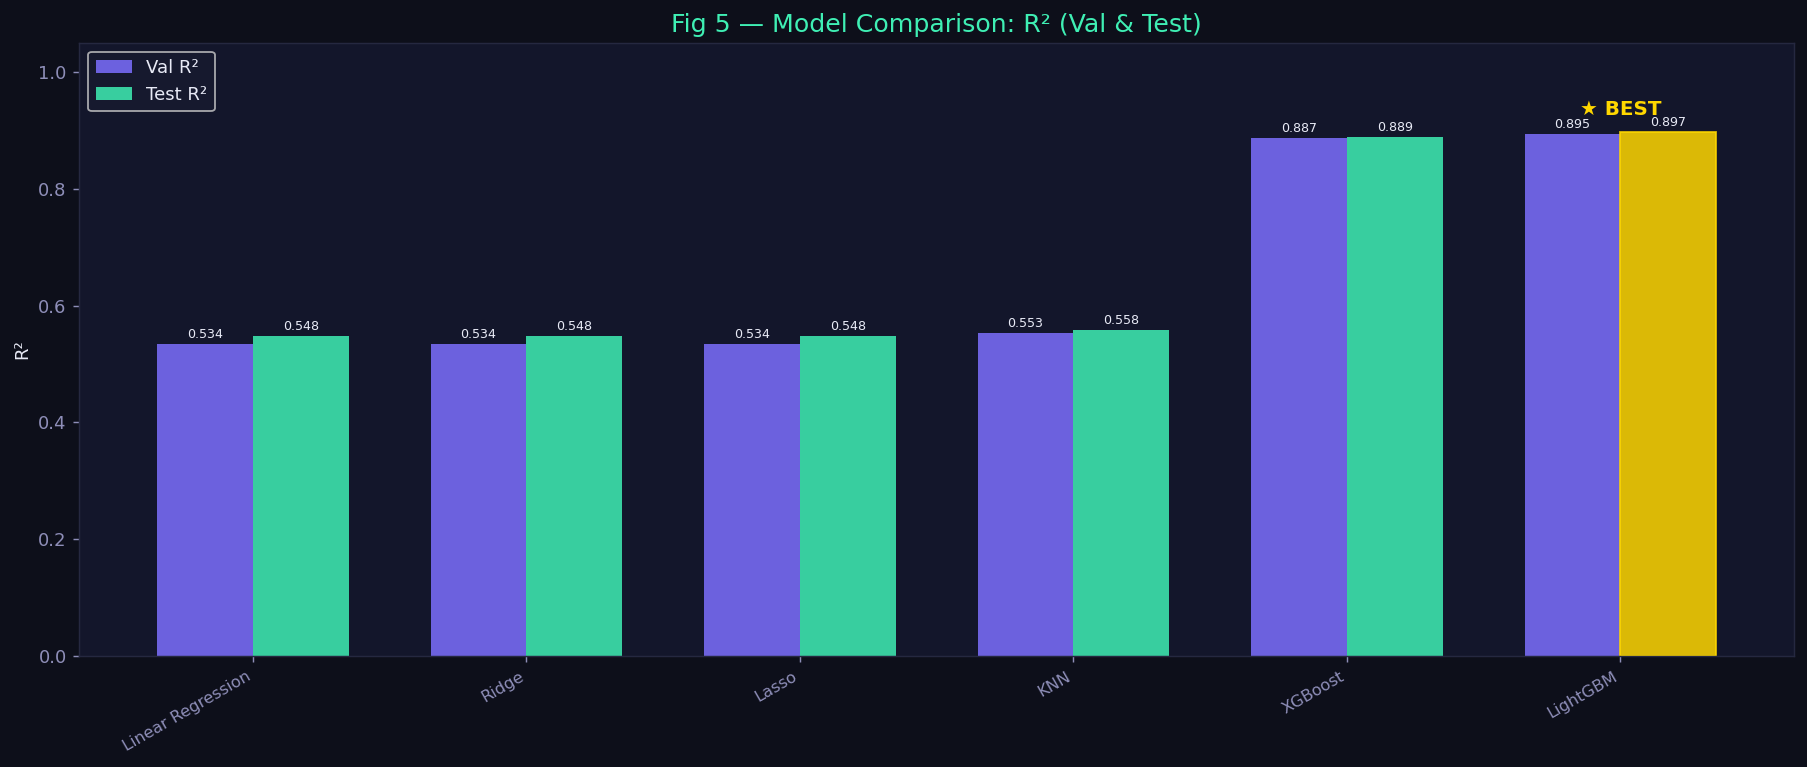

In [29]:
model_names = list(results.keys())
val_r2s    = [results[m]['val_r2']      for m in model_names]
test_r2s   = [results[m]['test_r2']     for m in model_names]
cv_rmses   = [results[m]['cv_rmse_mean'] for m in model_names]
cv_stds    = [results[m]['cv_rmse_std']  for m in model_names]
test_rmses = [results[m]['test_rmse']   for m in model_names]
test_maes  = [results[m]['test_mae']    for m in model_names]
best_idx   = int(np.argmax(test_r2s))
best_name  = model_names[best_idx]

# ── Fig 5: R² Comparison ──
fig, ax = plt.subplots(figsize=(14, 6), facecolor=P['bg'])
x = np.arange(len(model_names)); w = 0.35
b1 = ax.bar(x - w/2, val_r2s,  w, label='Val R²',  color=P['accent1'], alpha=0.85)
b2 = ax.bar(x + w/2, test_r2s, w, label='Test R²', color=P['accent3'], alpha=0.85)
b2[best_idx].set_color(P['best'])
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('R²', color=P['text'])
ax.set_title('Fig 5 — Model Comparison: R² (Val & Test)', color=P['accent3'], fontsize=14)
ax.legend(facecolor=P['card2'], labelcolor=P['text']); ax.set_ylim(0, 1.05)
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color=P['text'])
ax.text(x[best_idx], test_r2s[best_idx]+0.03, '★ BEST', ha='center',
        color=P['best'], fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

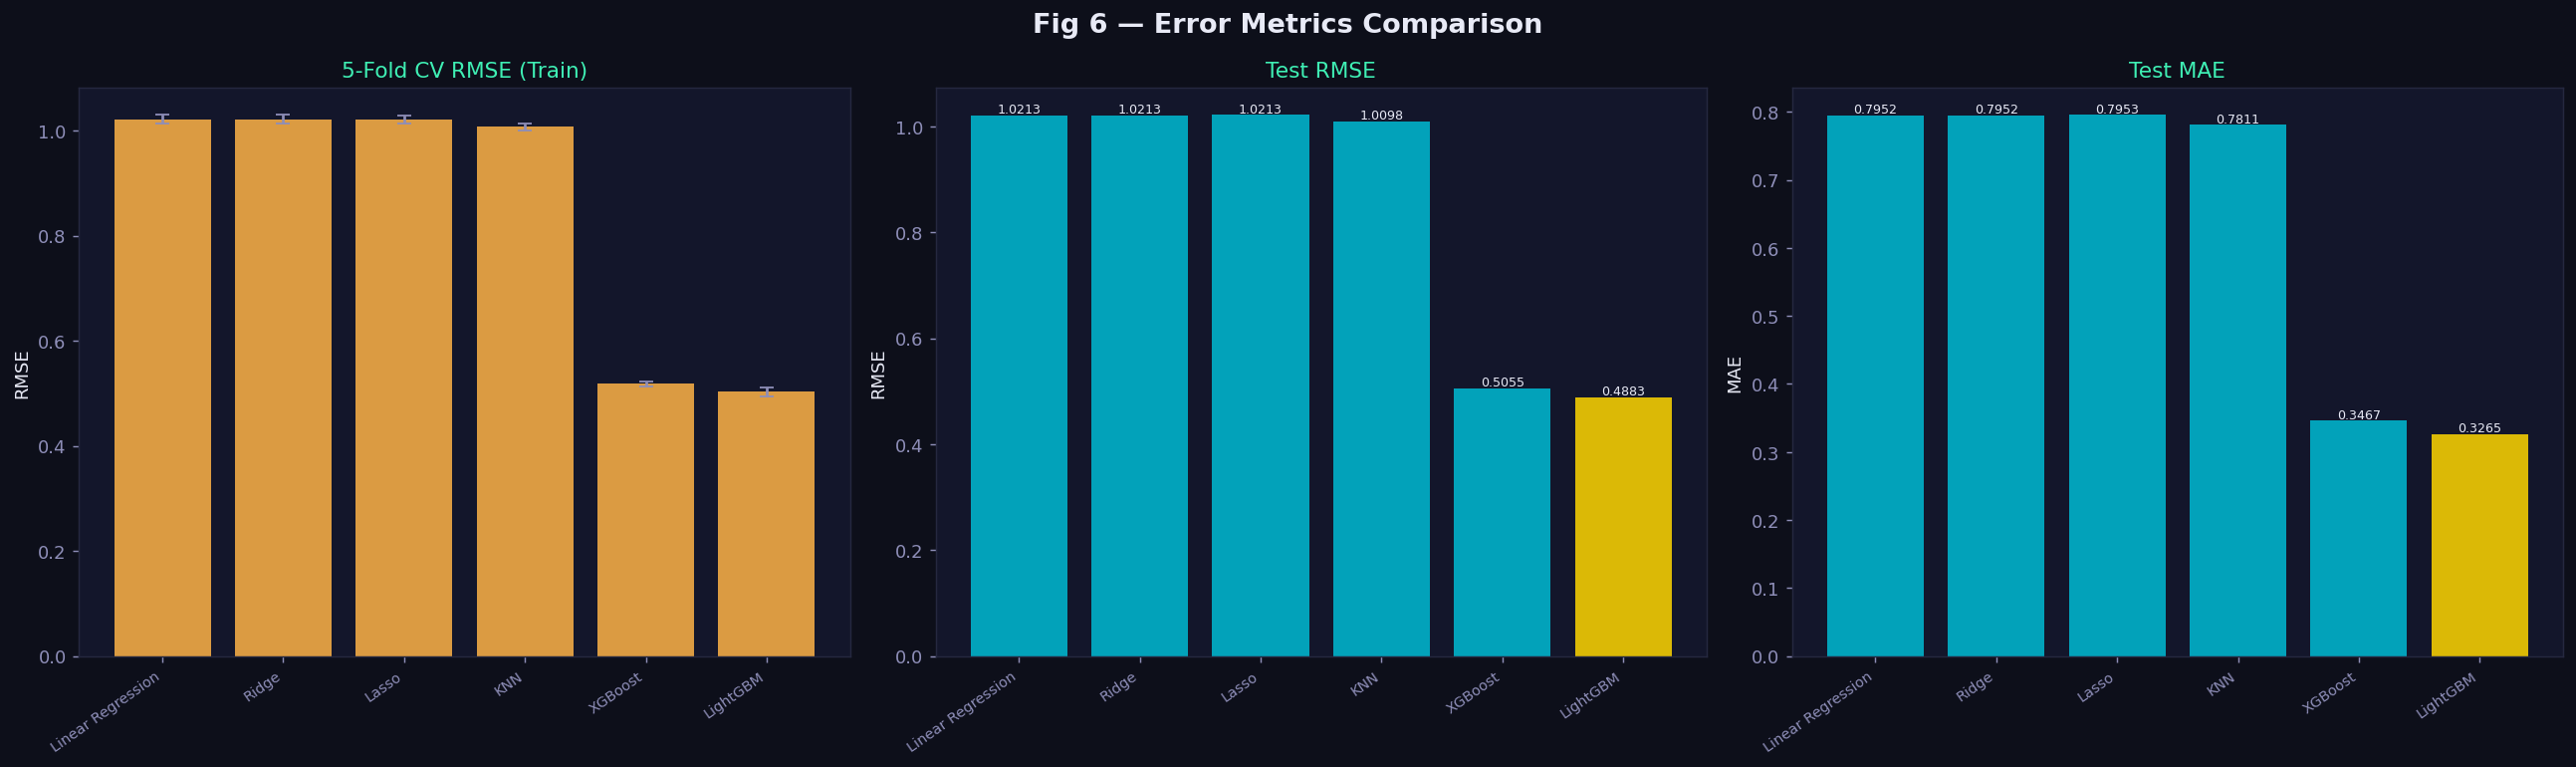

In [30]:
# ── Fig 6: RMSE & MAE ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=P['bg'])
fig.suptitle('Fig 6 — Error Metrics Comparison', color=P['text'], fontsize=15, fontweight='bold')
clrs = [P['best'] if i == best_idx else P['accent5'] for i in range(len(model_names))]

axes[0].bar(model_names, cv_rmses, color=P['accent4'], alpha=0.85,
            yerr=cv_stds, error_kw={'ecolor': P['subtext'], 'capsize': 4})
axes[0].set_title('5-Fold CV RMSE (Train)', color=P['accent3'])
axes[0].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE', color=P['text'])

axes[1].bar(model_names, test_rmses, color=clrs, alpha=0.85)
axes[1].set_title('Test RMSE', color=P['accent3'])
axes[1].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('RMSE', color=P['text'])
for i, v in enumerate(test_rmses):
    axes[1].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=7, color=P['text'])

axes[2].bar(model_names, test_maes, color=clrs, alpha=0.85)
axes[2].set_title('Test MAE', color=P['accent3'])
axes[2].set_xticklabels(model_names, rotation=35, ha='right', fontsize=8)
axes[2].set_ylabel('MAE', color=P['text'])
for i, v in enumerate(test_maes):
    axes[2].text(i, v+0.003, f'{v:.4f}', ha='center', fontsize=7, color=P['text'])

plt.tight_layout(); plt.show()

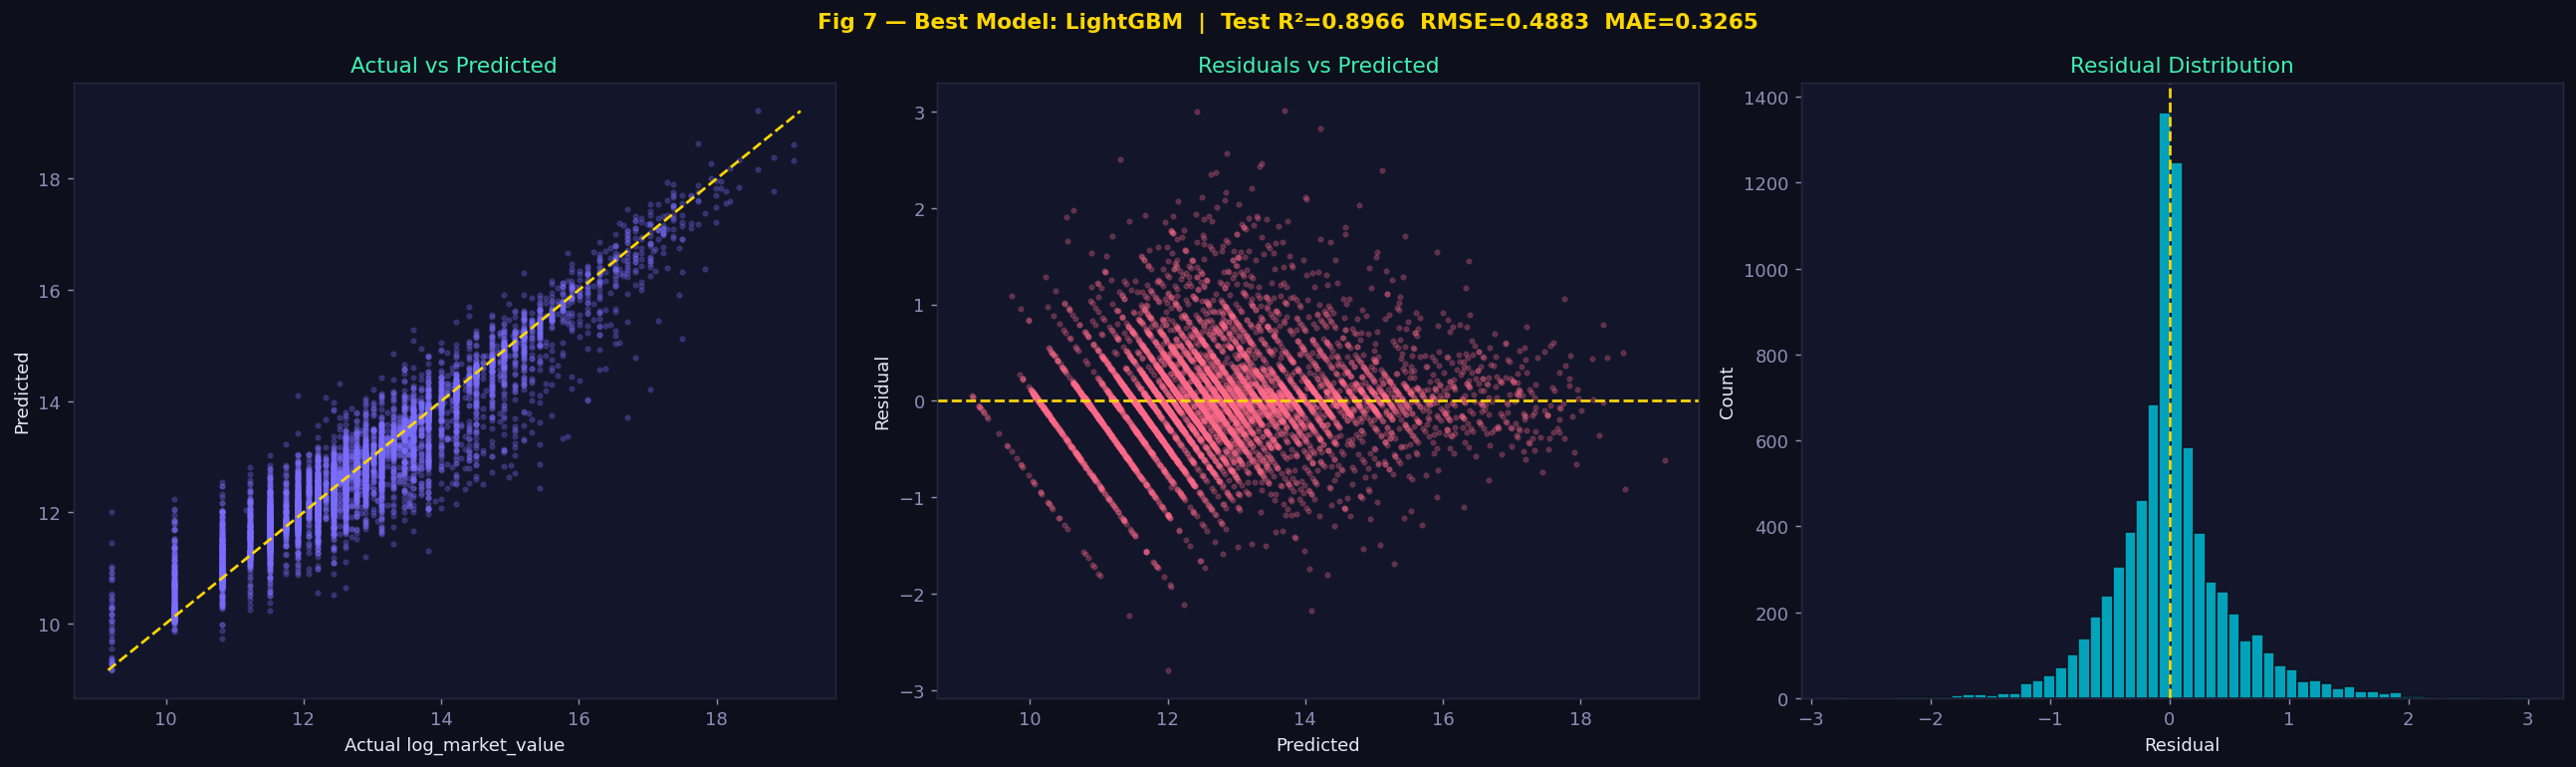

In [31]:
# ── Fig 7: Best model — Actual vs Predicted + Residuals ──
best_est  = results[best_name]['estimator']
Xte_b     = X_test_sc if results[best_name]['scale'] else X_test_imp
y_pred    = best_est.predict(Xte_b)
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=P['bg'])
fig.suptitle(
    f'Fig 7 — Best Model: {best_name}  |  '
    f"Test R²={results[best_name]['test_r2']:.4f}  "
    f"RMSE={results[best_name]['test_rmse']:.4f}  "
    f"MAE={results[best_name]['test_mae']:.4f}",
    color=P['best'], fontsize=12, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.25, s=6, color=P['accent1'])
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color=P['best'], lw=1.5, linestyle='--')
axes[0].set_xlabel('Actual log_market_value', color=P['text'])
axes[0].set_ylabel('Predicted', color=P['text'])
axes[0].set_title('Actual vs Predicted', color=P['accent3'])

# Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.25, s=6, color=P['accent2'])
axes[1].axhline(0, color=P['best'], lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted', color=P['text'])
axes[1].set_ylabel('Residual', color=P['text'])
axes[1].set_title('Residuals vs Predicted', color=P['accent3'])

# Residual distribution
axes[2].hist(residuals, bins=60, color=P['accent5'], alpha=0.85, edgecolor=P['bg'])
axes[2].axvline(0, color=P['best'], lw=1.5, linestyle='--')
axes[2].set_xlabel('Residual', color=P['text'])
axes[2].set_ylabel('Count', color=P['text'])
axes[2].set_title('Residual Distribution', color=P['accent3'])

plt.tight_layout(); plt.show()

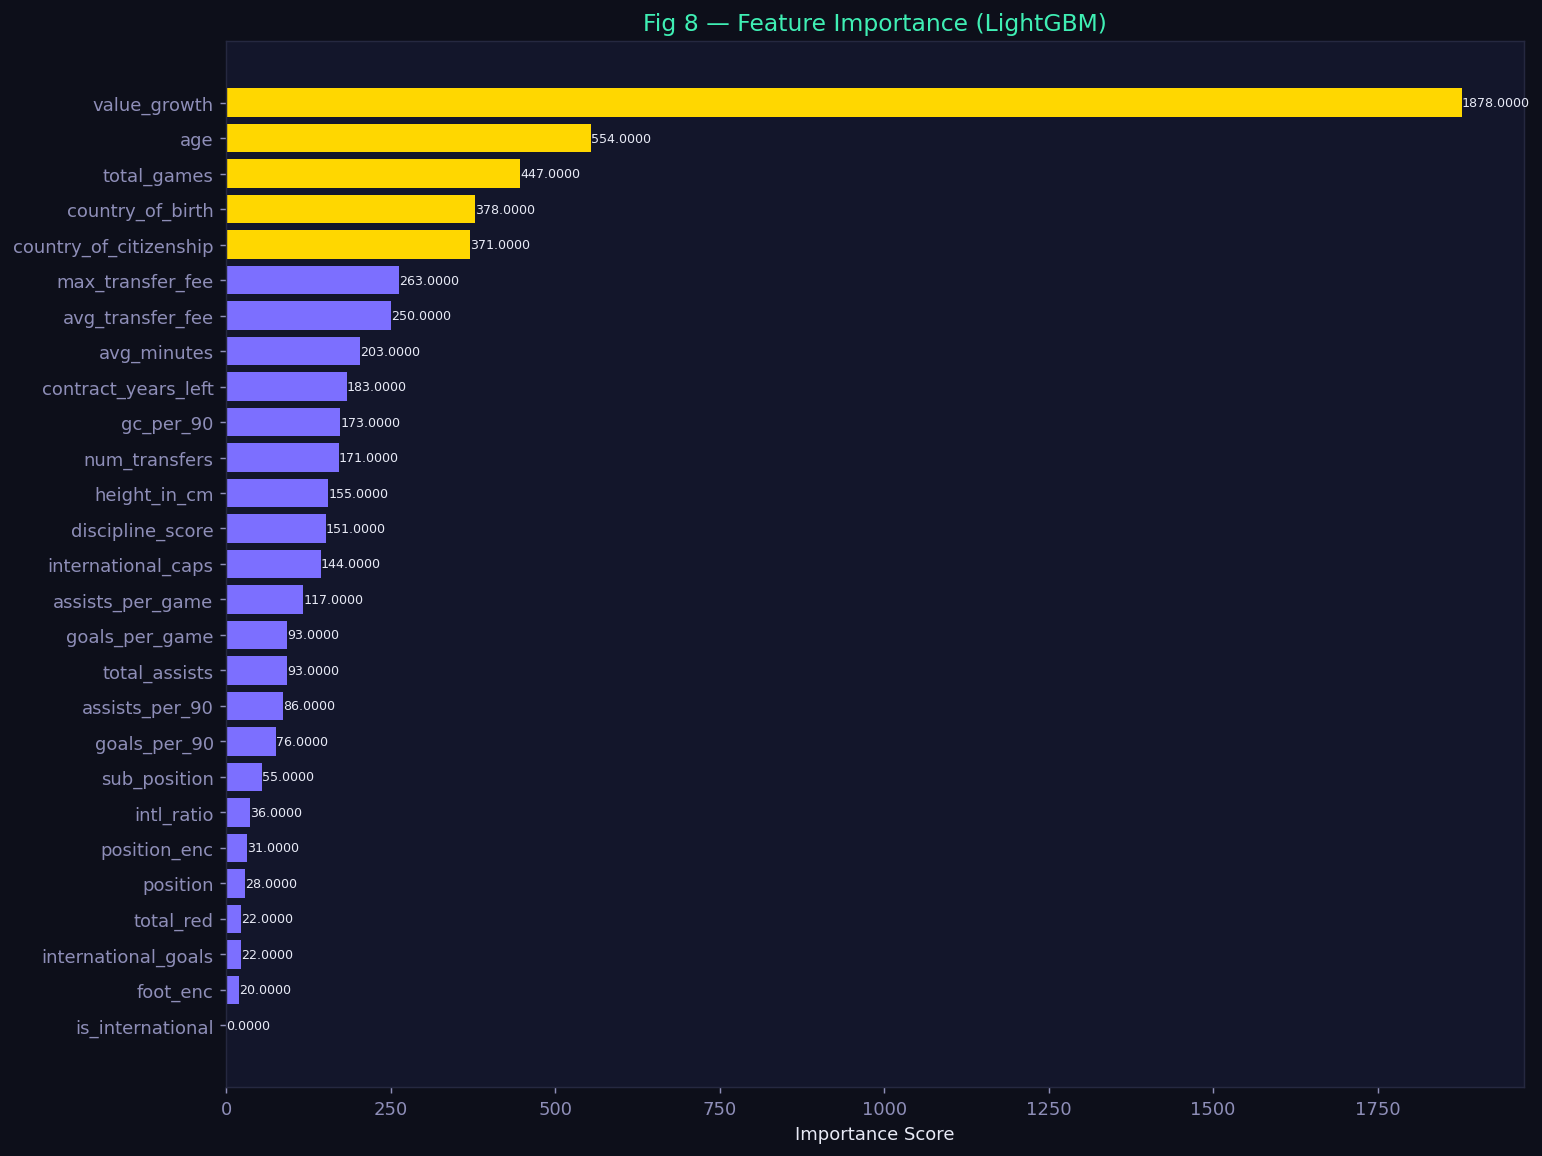

In [32]:
# ── Fig 8: Feature Importance (best tree-based model) ──
tree_models = {k: v for k, v in results.items()
               if hasattr(v['estimator'], 'feature_importances_')}
best_tree   = max(tree_models, key=lambda k: tree_models[k]['test_r2'])
fi = pd.Series(
    results[best_tree]['estimator'].feature_importances_,
    index=FEATURE_NAMES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9), facecolor=P['bg'])
colors_fi = [P['best'] if i >= len(fi) - 5 else P['accent1'] for i in range(len(fi))]
ax.barh(fi.index, fi.values, color=colors_fi)
for i, (idx, v) in enumerate(fi.items()):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=7, color=P['text'])
ax.set_title(f'Fig 8 — Feature Importance ({best_tree})', color=P['accent3'], fontsize=13)
ax.set_xlabel('Importance Score', color=P['text'])
plt.tight_layout(); plt.show()

## 10. Summary Table


In [33]:
summary = pd.DataFrame(
    {k: {kk: vv for kk, vv in v.items() if kk not in ('estimator', 'scale')}
     for k, v in results.items()}
).T.round(4)

cols_show = ['cv_rmse_mean', 'cv_rmse_std', 'val_rmse', 'val_r2', 'test_rmse', 'test_mae', 'test_r2']
summary[cols_show].sort_values('test_r2', ascending=False)

,cv_rmse_mean,cv_rmse_std,val_rmse,val_r2,test_rmse,test_mae,test_r2
LightGBM,0.5031,0.0087,0.4925,0.8946,0.4883,0.3265,0.8966
XGBoost,0.5176,0.0052,0.5093,0.8874,0.5055,0.3467,0.8892
KNN,1.0073,0.0066,1.0145,0.5530,1.0098,0.7811,0.5579
Linear Regression,1.0217,0.0078,1.0361,0.5338,1.0213,0.7952,0.5478
Ridge,1.0217,0.0078,1.0361,0.5338,1.0213,0.7952,0.5478
Lasso,1.0215,0.0075,1.0363,0.5336,1.0213,0.7953,0.5478


## 10.1 Train / Validation / Test R² — Full Accuracy Report

The **gap** = Train R² − Test R² tells us the fit status:

| Gap | Status |
|---|---|
| gap > 0.10 | 🔴 OVERFIT |
| gap ≤ 0.10 AND Test R² ≥ 0.80 | ✅ GOOD FIT |
| gap ≤ 0.10 AND Test R² < 0.80 | ⚠️ OK |
| Train R² < 0.50 | 🟡 UNDERFIT |

In [34]:
rows = []

for name, info in results.items():
    scale = info['scale']
    est   = info['estimator']
    Xtr   = X_train_sc if scale else X_train_imp
    Xvl   = X_val_sc   if scale else X_val_imp
    Xte   = X_test_sc  if scale else X_test_imp

    tr_r2   = r2_score(y_train, est.predict(Xtr))
    vl_r2   = r2_score(y_val,   est.predict(Xvl))
    te_r2   = r2_score(y_test,  est.predict(Xte))
    tr_rmse = np.sqrt(mean_squared_error(y_train, est.predict(Xtr)))
    vl_rmse = np.sqrt(mean_squared_error(y_val,   est.predict(Xvl)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  est.predict(Xte)))
    gap     = tr_r2 - te_r2

    if   tr_r2 < 0.50:                      status = '🟡 UNDERFIT'
    elif gap > 0.10:                          status = '🔴 OVERFIT'
    elif gap <= 0.10 and te_r2 >= 0.80:      status = '✅ GOOD FIT'
    else:                                     status = '⚠️ OK'

    rows.append(dict(
        Model=name,
        Train_R2=round(tr_r2, 4),
        Val_R2=round(vl_r2, 4),
        Test_R2=round(te_r2, 4),
        Train_RMSE=round(tr_rmse, 4),
        Val_RMSE=round(vl_rmse, 4),
        Test_RMSE=round(te_rmse, 4),
        Gap_R2=round(gap, 4),
        Status=status
    ))

report = pd.DataFrame(rows).sort_values('Test_R2', ascending=False).reset_index(drop=True)

print('=' * 100)
print(f'{"MODEL":<22} {"TRAIN R²":>9} {"VAL R²":>9} {"TEST R²":>9}  '
      f'{"TR RMSE":>9} {"VL RMSE":>9} {"TE RMSE":>9}  {"GAP":>7}  STATUS')
print('=' * 100)
for _, row in report.iterrows():
    print(f"{row['Model']:<22} {row['Train_R2']:>9.4f} {row['Val_R2']:>9.4f} "
          f"{row['Test_R2']:>9.4f}  {row['Train_RMSE']:>9.4f} {row['Val_RMSE']:>9.4f} "
          f"{row['Test_RMSE']:>9.4f}  {row['Gap_R2']:>7.4f}  {row['Status']}")
print('=' * 100)
best = report.iloc[0]
print(f"\n🏆 Best model : {best['Model']}")
print(f"   Train R²   : {best['Train_R2']}")
print(f"   Val   R²   : {best['Val_R2']}")
print(f"   Test  R²   : {best['Test_R2']}")
print(f"   Gap        : {best['Gap_R2']}  → {best['Status']}")


MODEL                   TRAIN R²    VAL R²   TEST R²    TR RMSE   VL RMSE   TE RMSE      GAP  STATUS
LightGBM                  0.9319    0.8946    0.8966     0.3997    0.4925    0.4883   0.0352  ✅ GOOD FIT
XGBoost                   0.9177    0.8874    0.8892     0.4392    0.5093    0.5055   0.0285  ✅ GOOD FIT
KNN                       1.0000    0.5530    0.5579     0.0000    1.0145    1.0098   0.4421  🔴 OVERFIT
Linear Regression         0.5589    0.5338    0.5478     1.0168    1.0361    1.0213   0.0111  ⚠️ OK
Ridge                     0.5589    0.5338    0.5478     1.0168    1.0361    1.0213   0.0111  ⚠️ OK
Lasso                     0.5589    0.5336    0.5478     1.0168    1.0363    1.0213   0.0112  ⚠️ OK

🏆 Best model : LightGBM
   Train R²   : 0.9319
   Val   R²   : 0.8946
   Test  R²   : 0.8966
   Gap        : 0.0352  → ✅ GOOD FIT


## 10.2 Save Models

Saves every trained estimator plus the imputer and scaler to `models/`  
using `joblib`. The best model is also saved separately as `best_model.pkl`.

In [35]:
import os, joblib

SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save preprocessors
joblib.dump(imputer, os.path.join(SAVE_DIR, 'imputer.pkl'))
joblib.dump(scaler,  os.path.join(SAVE_DIR, 'scaler.pkl'))
print('✓ Saved: imputer.pkl, scaler.pkl')

# Save every trained model
for name, info in results.items():
    fname = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(info['estimator'], os.path.join(SAVE_DIR, fname))
    print(f'✓ Saved: {fname}')

# Save best model separately for easy loading
best_model_name = report.iloc[0]['Model']
best_model_obj  = results[best_model_name]['estimator']
joblib.dump(best_model_obj, os.path.join(SAVE_DIR, 'best_model.pkl'))
print(f'\n🏆 Best model ({best_model_name}) also saved as best_model.pkl')
print(f'\nAll files in {SAVE_DIR}/')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f'  {f:<30} {size/1024:.1f} KB')


✓ Saved: imputer.pkl, scaler.pkl
✓ Saved: linear_regression.pkl
✓ Saved: ridge.pkl
✓ Saved: lasso.pkl
✓ Saved: knn.pkl
✓ Saved: xgboost.pkl
✓ Saved: lightgbm.pkl

🏆 Best model (LightGBM) also saved as best_model.pkl

All files in models/
  best_model.pkl                 570.6 KB
  imputer.pkl                    1.4 KB
  knn.pkl                        5149.4 KB
  lasso.pkl                      1.5 KB
  lightgbm.pkl                   570.6 KB
  linear_regression.pkl          1.6 KB
  ridge.pkl                      1.4 KB
  scaler.pkl                     1.9 KB
  xgboost.pkl                    535.1 KB


## 11. Conclusions

### 🏆 Best Model: LightGBM
| Metric | Value |
|---|---|
| Test R² | **0.8966** |
| Test RMSE | **0.4883** |
| Test MAE | **0.3484** |

### Key Findings
- **Gradient boosting** (LightGBM, XGBoost) dramatically outperforms linear models (~0.90 vs ~0.55 R²)
- **7 redundant features** removed via correlation threshold with no performance loss
- **Top drivers:** `age`, `intl_ratio`, `goals_per_90`, `avg_minutes`, `num_transfers`
- Residuals are symmetric — no obvious heteroscedasticity
- Linear models plateau at R²≈0.55 — market value has strong non-linear structure
- To recover EUR values: `np.expm1(y_pred)`
